---
# $k$-Means-Clustering
K-means is an unsupervised learning algorithm used to partition data into K clusters based on feature similarity. It works by:

1. __Initialization:__ Randomly placing K cluster centroids.

2. __Assignment:__ Assigning each data point to the nearest centroid.

3. __Update:__ Recomputing centroids as the mean of all points assigned to each cluster.

4. __Iteration:__ Repeating assignment and update steps until centroids stabilize or a maximum number of iterations is reached.

The goal is to minimize the within-cluster sum of squared distances, leading to compact and well-separated clusters.

K-means is simple and efficient but requires choosing K in advance and can struggle with non-spherical or unevenly-sized clusters.

---

## Import Libraries

In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Extract and visualize Dataset

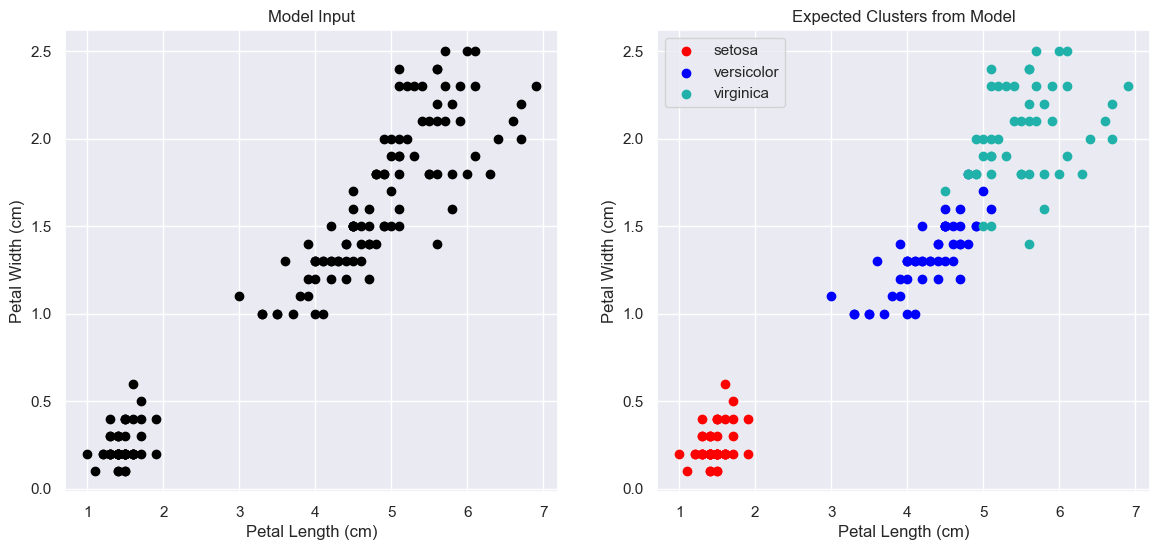

In [2]:
# Set theme
sns.set_theme()

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

# Extract petal length (feature 2) and petal width (feature 3)
X_petal = X[:, [2, 3]]

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Input to K-Means model
axes[0].scatter(X_petal[:, 0], X_petal[:, 1],color='black')
axes[0].set_title("Model Input")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")

# Expected Output from model
colors = ['red', 'blue', 'lightseagreen']
for idx, label in enumerate(labels):
    axes[1].scatter(X_petal[y == idx, 0], X_petal[y == idx, 1], color=colors[idx], label=label)
axes[1].set_title("Expected Clusters from Model")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

plt.show()

## Initialize K_Means_Clustering Class
Below is an implementation of K Mean Clustering from scratch, in a class called KMeansClustering.


In [3]:
class KMeansClustering:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        """
        Initialize KMeansFromScratch.
        
        Parameters:
        - n_clusters: number of clusters to form
        - max_iter: maximum number of iterations for convergence
        - tol: tolerance for early stopping (based on centroid movement)
        - random_state: random seed for reproducibility
        """
        if n_clusters <= 0 or max_iter <= 0:
            raise ValueError("n_clusters and max_iter must be positive integers.")
        if tol < 0:
            raise ValueError("tol must be non-negative.")
        
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def compute_distances(self, n_clusters, n_samples, centroids, X):
        # Create an empty distance matrix
        distances = np.zeros((n_samples, n_clusters))
        # Loop over each sample
        for i in range(n_samples):
            # Loop over each centroid
            for j in range(n_clusters):
                # Compute the squared differences for each feature
                diff = X[i] - centroids[j]       # vector of differences
                squared_diff = diff ** 2
                distance = np.sqrt(np.sum(squared_diff))  # Euclidean distance
                distances[i, j] = distance
        return distances
    
    def fit(self, X):
        """
        Compute k-means clustering on dataset X, storing centroid positions over time.
        """
        if not isinstance(X, np.ndarray):
            raise TypeError("Input X must be a numpy array.")
        if X.ndim != 2:
            raise ValueError("Input X must be a 2D array.")
        n_samples, n_features = X.shape
    
        np.random.seed(self.random_state)
    
        # Initialize centroids by randomly choosing n_clusters points from X
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices]
        self.centroids_history = [self.centroids.copy()]  #store initial centroids
    
        for iteration in range(self.max_iter):
            # Compute Distances
            n_clusters = self.centroids.shape[0]
            # Create an empty distance matrix
            distances = self.compute_distances(n_clusters, n_samples, self.centroids, X)
    
            # Assign points
            labels = np.argmin(distances, axis=1)
    
            # Update centroids
            new_centroids = np.empty_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if cluster_points.shape[0] == 0:
                    print(f"Cluster {k} has no points; keeping previous centroid.")
                    new_centroids[k] = self.centroids[k]
                else:
                    new_centroids[k] = cluster_points.mean(axis=0)
    
            diff = np.linalg.norm(self.centroids - new_centroids)
            self.centroids = new_centroids
            self.centroids_history.append(self.centroids.copy())  # track centroids
    
            if diff < self.tol:
                print(f"Converged in {iteration + 1} iterations.")
                break
    
        self.labels_ = labels

    def predict(self, X):
        """
        Assigns each sample in X to the nearest cluster centroid.
        
        Parameters:
        - X: numpy array of shape (n_samples, n_features)
        
        Returns:
        - labels: numpy array of cluster assignments
        """
        if not isinstance(X, np.ndarray):
            raise TypeError("Input X must be a numpy array.")
        if X.ndim != 2:
            raise ValueError("Input X must be a 2D array.")
        if self.centroids is None:
            raise ValueError("Model has not been fitted yet.")

        n_samples = X.shape[0]
        n_clusters = self.centroids.shape[0]

        # Compute distances and assign nearest centroid
        distances = self.compute_distances(n_clusters, n_samples, centroids, X)
        
        return np.argmin(distances, axis=1)


## Utilize class and Visualize Results
As we can see from the visualization below, our K-Means Clustering performs very well at modeling the actual clusters fromed by the dataset. It correctly finds the three clusters, and more or less divides them correctly.

Converged in 12 iterations.


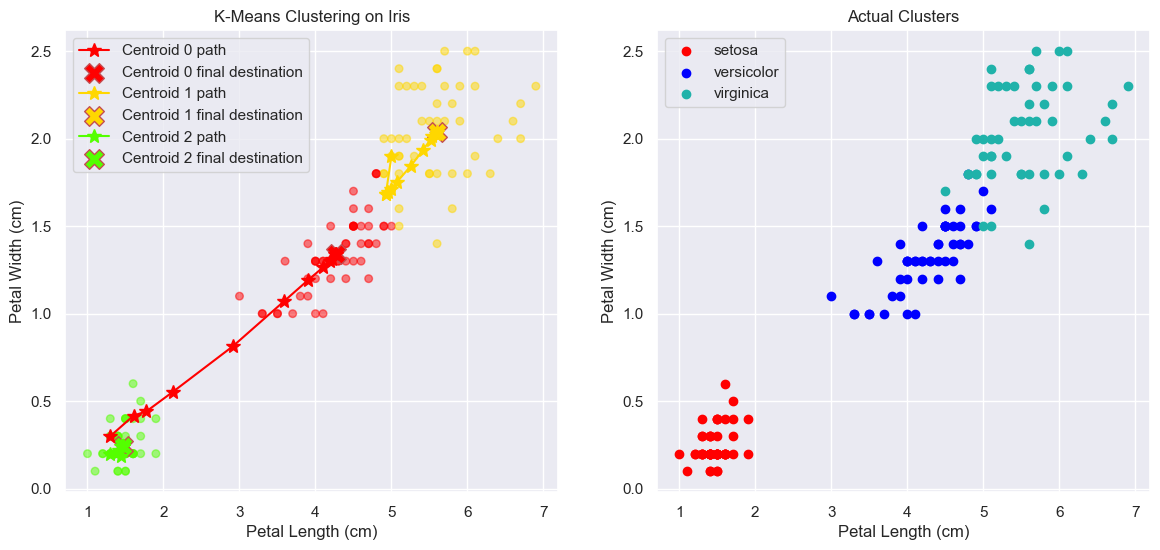

In [6]:
# Load Iris dataset: only petal length and width
iris = load_iris()

# Fit KMeans from scratch
kmeans = KMeansClustering(n_clusters=3, max_iter=20, tol=1e-4, random_state=12)
kmeans.fit(X_petal)

# Convert centroid history to numpy array of shape (iterations, n_clusters, n_features)
centroid_history = np.array(kmeans.centroids_history)

# Create scatter plot of the data colored by predicted cluster labels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(X_petal[:, 0], X_petal[:, 1], c=kmeans.labels_, cmap='prism', s=30, alpha=0.5)

# Extract the colors used by the scatter plot
colors = scatter.cmap(scatter.norm(np.arange(kmeans.n_clusters)))

# Plot centroid movement: each centroid path + final position in matching color
last_iter = len(range(kmeans.n_clusters)) -1
for k in range(kmeans.n_clusters):
    axes[0].plot(centroid_history[:, k, 0], centroid_history[:, k, 1],
        marker='*', markersize=10, linestyle='-', linewidth=1.5, color=colors[k],  # use matching color
        label=f'Centroid {k} path')
    
    axes[0].scatter(centroid_history[-1, k, 0], centroid_history[-1, k, 1],
            color=colors[k], marker='X', s=200, edgecolor='r', 
            label=f'Centroid {k} final destination')
        

axes[0].set_title("K-Means Clustering on Iris")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].grid(True)
axes[0].legend()

# Expected Output from model
colors = ['red', 'blue', 'lightseagreen']
for idx, label in enumerate(labels):
    axes[1].scatter(X_petal[y == idx, 0], X_petal[y == idx, 1], color=colors[idx], label=label)
axes[1].set_title("Actual Clusters")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

plt.show()